In [ ]:
# Mount into drive

from google.colab import drive

drive.mount("/content/drive")
#! ls /content/drive
%cd '/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB'

!pip install -r requirements_jing.txt


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB


In [ ]:
import os
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Cell 1: Imports (Make sure these are at the top of your notebook)
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys
import yaml
from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset
from training.trainer import Trainer, Config

In [ ]:
print(os.getcwd())

/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB


In [ ]:

with open("configs/tlob.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [ ]:
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000072
Shape after label creation and NaN drop: (4817823, 44)
Label distribution:
label
1    0.468476
2    0.267162
0    0.264362
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

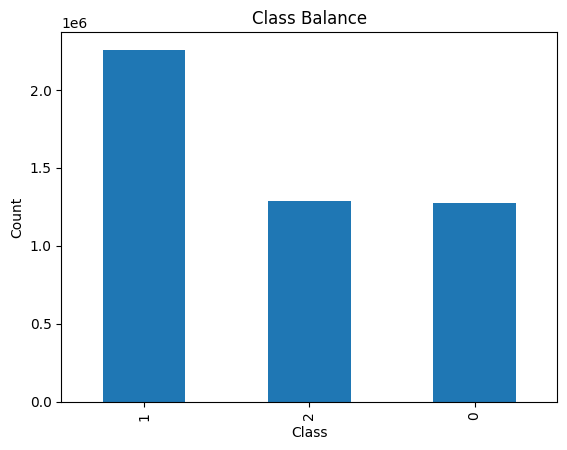

In [ ]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [ ]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372476, Val=722673, Test=722674


2807

In [ ]:
train_df.head()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,70292.523438,70291.828125,70291.812500,70291.460938,70290.242188,70288.500000,70288.476562,70288.468750,70288.320312,70287.609375,...,0.024139,0.032386,0.067155,0.00867,0.011392,0.142374,70292.53125,0.007812,0.326259,2
51,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70288.906250,70288.500000,70288.320312,70286.593750,...,0.092469,0.032386,0.035563,0.05280,0.215270,0.008670,70292.53125,0.007812,-0.322852,2
52,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70288.500000,70288.320312,70286.593750,70286.578125,...,0.024139,0.032386,0.035563,0.21527,0.008670,0.116370,70292.53125,0.007812,0.100118,2
53,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70289.007812,70288.500000,70288.320312,70286.593750,...,0.024139,0.032386,0.035563,0.21527,0.008670,0.116370,70292.53125,0.007812,-0.175461,2
54,70292.523438,70291.812500,70291.460938,70291.437500,70290.242188,70289.359375,70289.007812,70288.500000,70288.320312,70286.593750,...,0.032386,0.035563,0.006109,0.21527,0.008670,0.116370,70292.53125,0.007812,-0.152728,2


In [ ]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()


Columns selected for scaling (43): ['b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9']...
Normalization applied.


0

In [ ]:
train_df_norm.head()

,b0,b1,b2,b3,b4,b5,b6,b7,b8,b9,...,aq4,aq5,aq6,aq7,aq8,aq9,mid_price,spread,vol_imbalance_10,label
50,-0.549907,-0.540036,-0.539559,-0.539361,-0.539422,-0.536455,-0.536109,-0.530209,-0.529882,-0.529500,...,-0.109744,-0.150803,-0.205032,-0.157615,-0.141587,-0.070604,-0.522077,0.30258,1.011342,2
51,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.535998,-0.530201,-0.529882,-0.529763,...,-0.043730,-0.150803,-0.216450,-0.126767,0.027404,-0.170913,-0.522077,0.30258,-0.463732,2
52,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.536103,-0.530248,-0.530329,-0.529767,...,-0.109743,-0.150803,-0.216450,-0.013197,-0.143844,-0.090113,-0.522077,0.30258,0.497447,2
53,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.535971,-0.530201,-0.529882,-0.529763,...,-0.109743,-0.150803,-0.216450,-0.013197,-0.143844,-0.090113,-0.522077,0.30258,-0.128794,2
54,-0.549907,-0.540040,-0.539650,-0.539367,-0.539422,-0.536232,-0.535971,-0.530201,-0.529882,-0.529763,...,-0.101776,-0.149012,-0.227094,-0.013197,-0.143844,-0.090113,-0.522077,0.30258,-0.077133,2


In [ ]:
config.sequence_length = 100

In [ ]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float16).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float16).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float16).values

T = config.sequence_length
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision=np.float16)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision=np.float16)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision=np.float16)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()


Sequence Creation Complete:
X_train_seq shape: (3372376, 100, 43), y_train_seq shape: (3372376,)
X_val_seq shape: (722573, 100, 43), y_val_seq shape: (722573,)
X_test_seq shape: (722574, 100, 43), y_test_seq shape: (722574,)


0

In [ ]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

#train_loader = DataLoader(train_dataset, batch_size=config.train.batch_size, shuffle=True) # num_workers/pin_memory optional
#val_loader = DataLoader(val_dataset, batch_size=config.train.batch_size, shuffle=False)
#test_loader = DataLoader(test_dataset, batch_size=config.train.batch_size, shuffle=False)
# gc.collect()

In [ ]:
print(config.model.type)

tlob_model


In [ ]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([1024, 43, 100])

Datasets and DataLoaders created.
Number of training batches: 3294
Number of validation batches: 706
Number of testing batches: 706
Input Size: (1, 43)


In [ ]:
from experiment_runner.experiment_runner import run_single_trial, run_parameter_sweep, orchestrate_experiment
from experiment_runner.experiment_runner import save_df
base_dir = 'results/tlob/'
trial_name = 'test_tlob_single_trial'
trainer, training_history, final_results = run_single_trial(trial_config=config,
                           train_dataset=train_dataset,
                           val_dataset=val_dataset,
                           test_dataset=test_dataset,
                           device=torch.device(device),
                           base_dir=base_dir,
                           trial_name=trial_name,
                           verbose=True)

Created experiment directory: results/tlob/test_tlob_single_trial

--- Running Trial: test_tlob_single_trial ---
Config: {'data_path': 'data/coinbase_book_2024-10-29_2024-11-11', 'num_files': None, 'precision': None, 'clean_strategy': 'dropna', 'num_levels_features': 10, 'label_price_type': 'simple_midpoint', 'label_price_levels': 1, 'label_price_col': None, 'label_method': 'tlob', 'label_k': 50, 'label_h': 50, 'label_alpha': 'auto', 'verbose': True, 'sequence_length': 100, 'output_path': 'results/', 'output_name': 'tlob', 'split_fractions': <training.trainer.Config object at 0x7fe170f8e390>, 'seed': 42, 'train': <training.trainer.Config object at 0x7fe29cbb7fd0>, 'model': <training.trainer.Config object at 0x7fe29d8f4d10>, 'loss': None, 'optimizer': <training.trainer.Config object at 0x7fe238daf5d0>, 'scheduler': <training.trainer.Config object at 0x7fe294002e10>}
Configuration saved to results/tlob/test_tlob_single_trial/trial_config.yaml
One batch shape: torch.Size([1024, 43, 100])


/content/drive/Othercomputers/MyMac/CS7643_DL/crytpo_DLOB/training/trainer.py:236: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.use_amp):


  ↳ Val loss: 0.7977 — Val F₁: 0.6440
Epoch finished in 716.1543250230006 seconds
  ↳ New best model (val_loss=0.7977), checkpoint saved.
Epoch[Batch]: [2][0/3294]	Avg_Loss 0.718 (0.748)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][329/3294]	Avg_Loss 0.714 (0.746)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][658/3294]	Avg_Loss 0.737 (0.743)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][987/3294]	Avg_Loss 0.743 (0.741)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][1316/3294]	Avg_Loss 0.682 (0.739)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][1645/3294]	Avg_Loss 0.707 (0.737)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][1974/3294]	Avg_Loss 0.683 (0.736)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][2303/3294]	Avg_Loss 0.694 (0.735)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][2632/3294]	Avg_Loss 0.716 (0.733)	 Time 0.119 (0.118)	
Epoch[Batch]: [2][2961/3294]	Avg_Loss 0.704 (0.732)	 Time 0.118 (0.118)	
Epoch[Batch]: [2][3290/3294]	Avg_Loss 0.661 (0.731)	 Time 0.117 (0.118)	
Epoch 2/20 — Train loss: 0.7306 — Train F₁: 0.6839
  ↳ Val loss: 

In [ ]:
training_history

{'epochs': array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19., 20.]),
 'train_loss': [0.7483389115982108,
  0.730589586913525,
  0.7218286263151387,
  0.7160728611113631,
  0.7116476327573729,
  0.7078675263050453,
  0.7040608035514148,
  0.7007225674013424],
 'train_score': [array(0.66205174, dtype=float32),
  array(0.68391323, dtype=float32),
  array(0.6882037, dtype=float32),
  array(0.6907186, dtype=float32),
  array(0.69290733, dtype=float32),
  array(0.6952955, dtype=float32),
  array(0.69874096, dtype=float32),
  array(0.7002256, dtype=float32)],
 'val_loss': [0.7976934658557712,
  0.7758748466199639,
  0.7697363758873184,
  0.7744007773354663,
  0.7704218149965861,
  0.7738016197114008,
  0.7746728605541398,
  0.7853836755055145],
 'val_score': [array(0.6440394, dtype=float32),
  array(0.66205025, dtype=float32),
  array(0.6663408, dtype=float32),
  array(0.66225135, dtype=float32),
  array(0.66627365, dtype=float32),
  

In [ ]:
final_results

{'epochs': 20,
 'train_loss': 0.7007225674013424,
 'train_score': 0.7002255916595459,
 'val_loss': 0.7853836755055145,
 'val_score': 0.6597793102264404,
 'test_loss': 0.724670360842644,
 'test_score': 0.6812628507614136}

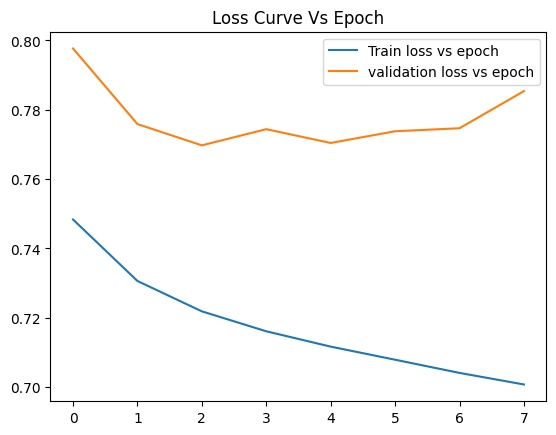

In [ ]:
pd.Series(training_history['train_loss']).plot(label="Train loss vs epoch")
pd.Series(training_history['val_loss']).plot(label="validation loss vs epoch")
plt.title("Loss Curve Vs Epoch")
plt.legend()
plt.show()

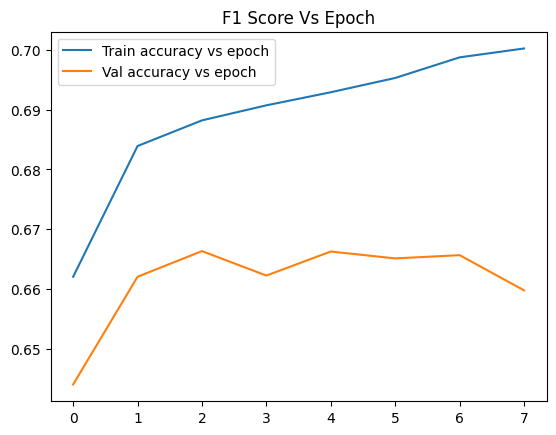

In [ ]:
pd.Series((training_history['train_score'])).astype('float').plot(label="Train accuracy vs epoch")
pd.Series((training_history['val_score'])).astype('float').plot(label="Val accuracy vs epoch")
plt.title("F1 Score Vs Epoch")
plt.legend()
plt.show()

In [ ]:
pd.Series(training_history['val_score'])

,0
0,0.6440394
1,0.66205025
2,0.6663408
3,0.66225135
4,0.66627365
5,0.6651196
6,0.6656637
7,0.6597793
